In [6]:
from run_model_PANDA import run_model
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Running model on infants normally

In [2]:
# process_sheet="Analysis"

listfile = r"C:\Users\franc\Box\Rehab Robotics Lab\Projects\PANDA Gym (# 834084)\Personnel\Students & RAs\Francis Sowande\Aim 2\Analysis.xlsx"
image_folder=r"C:\Users\franc\Box\Rehab Robotics Lab\Projects\PANDA Gym (# 834084)\Personnel\Students & RAs\Francis Sowande\Aim 2\Analysis 1"

df= pd.read_excel(listfile)

aim=1


# dates=pd.to_datetime(df.Date)
subid=df.subjectID
subid_u=pd.unique(subid)

tot=len(subid_u)
# check=[16]

for i in range(tot):
# for i in range(1):
# for id in check:
    id=subid_u[i]
    print("SUBJECT ID: ", str(id).zfill(3))
    subject=df.loc[df['subjectID']==id]

    sub_dates_ind=(pd.unique(subject.Date))
    
    sub_dates=pd.to_datetime(sub_dates_ind)
    try:

        for j in range(len(sub_dates)):
            trial_date=sub_dates[j]
            print("Date: ", str(trial_date))

            baby = run_model(aim, id, trial_date.month, trial_date.day, trial_date.year)

            metrics = baby.comp()
            # baby.save_XY(image_folder)

            trial=df.loc[(df['subjectID']==id)&(df['Date']==sub_dates_ind[j])]


            # display(metrics)
            col_names=["MAE X", "MAE Y", "Corr X", "Corr Y", "Mean MAE", "Mean Corr"]

            for nme in col_names:
                # trial[nme]=metrics.loc[0,nme]
                df.loc[(df['subjectID']==id)&(df['Date']==sub_dates_ind[j]),nme]=metrics.loc[0,nme]
            
            # display(trial)
            # exit()

            # df.loc[(df['subjectID']==id)&(df['Date']==sub_dates_ind[j])]=trial
            # display(df.loc[(df['subjectID']==id)&(df['Date']==sub_dates_ind[j])])

            df.to_excel(listfile, index=False)

    except:
        print("------------------Error",id)


SUBJECT ID:  006
Date:  2021-08-18 00:00:00
C:\Users\franc\Box\Rehab Robotics Lab\Projects\PANDA Gym (# 834084)\Data\Trials\Aim I\833180_006\08-18-2021\Mat\2021_08_18_833180_006_mat_session2.csv
------------------Error 6
SUBJECT ID:  004
Date:  2021-07-30 00:00:00
C:\Users\franc\Box\Rehab Robotics Lab\Projects\PANDA Gym (# 834084)\Data\Trials\Aim I\833180_004\07-30-2021\Mat\2021_07_30_833180_004_mat_session2.csv
done init
done ID
SUBJECT ID:  002
Date:  2021-06-14 00:00:00
------------------Error 2
SUBJECT ID:  105
Date:  2025-01-13 00:00:00
C:\Users\franc\Box\Rehab Robotics Lab\Projects\PANDA Gym (# 834084)\Data\Trials\Aim I\833180_105\01-13-2025\Mat\2025_01_13_833180_105_mat_session2.csv
done init
done ID
SUBJECT ID:  011
Date:  2022-03-10 00:00:00
C:\Users\franc\Box\Rehab Robotics Lab\Projects\PANDA Gym (# 834084)\Data\Trials\Aim I\833180_011\03-10-2022\Mat\2022_03_10_833180_011_mat_session2.csv
done init
done ID
SUBJECT ID:  012
Date:  2022-06-09 00:00:00
C:\Users\franc\Box\Rehab R

In [ ]:
# process_sheet="Analysis"
file_direct=r"C:\Users\franc\Box\Rehab Robotics Lab\Projects\PANDA Gym (# 834084)\Personnel\Students & RAs\Francis Sowande\Aim 2"
listfile = file_direct+"\\Analysis 2 comp.xlsx"
image_folder=r"C:\Users\franc\Box\Rehab Robotics Lab\Projects\PANDA Gym (# 834084)\Personnel\Students & RAs\Francis Sowande\Aim 2\Analysis 2"

df= pd.read_excel(listfile)

aim=1


# dates=pd.to_datetime(df.Date)
subid=df.subjectID
subid_u=pd.unique(subid)

tot=len(subid_u)
optim="none"

# angles=[30,60,90,120,150,180,210,240]
# angles=[20,30,40,60,75,90]
# check=[16]

# for ang in angles:
# for i in range(tot):
for i in range(1):
# for id in check:
    id=subid_u[i]
    print("SUBJECT ID: ", str(id).zfill(3))
    subject=df.loc[df['subjectID']==id]

    sub_dates_ind=(pd.unique(subject.Date))
    
    sub_dates=pd.to_datetime(sub_dates_ind)
    # try:

    for j in range(len(sub_dates)):
        trial_date=sub_dates[j]
        print("Date: ", str(trial_date))

        baby = run_model(aim, id, trial_date.month, trial_date.day, trial_date.year)

        head_h_ratio_chest=df.loc[(df['subjectID']==id)&(df['Date']==sub_dates_ind[j])&(df['optim']==optim),"head height ratio"].item()
        r_head_ratio=df.loc[(df['subjectID']==id)&(df['Date']==sub_dates_ind[j])&(df['optim']==optim),"head rad ratio"].item()
        trunk_h_ratio=df.loc[(df['subjectID']==id)&(df['Date']==sub_dates_ind[j])&(df['optim']==optim),"trunk height ratio"].item()
        r_trunk_ratio=df.loc[(df['subjectID']==id)&(df['Date']==sub_dates_ind[j])&(df['optim']==optim),"trunk rad ratio"].item()        

        whead=np.mean(baby.calc.pose.get_len(16,17))
        Rhead=np.mean(baby.calc.pose.get_len(16,17))*r_head_ratio
        z_init_chest=np.mean(baby.calc.pose.Z[1,0:300])
        zface=np.mean(baby.calc.pose.Z[1,0:300])*head_h_ratio_chest
        Zcenter_head=Rhead-zface

        df.loc[(df['subjectID']==id)&(df['Date']==sub_dates_ind[j])&(df['optim']==optim),"w head"]=whead
        df.loc[(df['subjectID']==id)&(df['Date']==sub_dates_ind[j])&(df['optim']==optim),"Rhead"]=Rhead
        df.loc[(df['subjectID']==id)&(df['Date']==sub_dates_ind[j])&(df['optim']==optim),"Zface"]=zface
        df.loc[(df['subjectID']==id)&(df['Date']==sub_dates_ind[j])&(df['optim']==optim),"Zcenter head"]=Zcenter_head
        
        whip=baby.calc.utrunk_w
        Rtrunk=baby.calc.utrunk_w*r_trunk_ratio
        z_init_hip=np.mean(baby.calc.pose.mid_hip[2,0:10])
        ztrunk=np.mean(baby.calc.pose.mid_hip[2,0:10])*trunk_h_ratio
        Zcenter_trunk=Rtrunk-ztrunk

        
        df.loc[(df['subjectID']==id)&(df['Date']==sub_dates_ind[j])&(df['optim']==optim),"w hip"]=whip
        df.loc[(df['subjectID']==id)&(df['Date']==sub_dates_ind[j])&(df['optim']==optim),"Rtrunk"]=Rtrunk
        df.loc[(df['subjectID']==id)&(df['Date']==sub_dates_ind[j])&(df['optim']==optim),"Zhip"]=ztrunk
        df.loc[(df['subjectID']==id)&(df['Date']==sub_dates_ind[j])&(df['optim']==optim),"Zcenter Hip"]=Zcenter_trunk


        # print(baby.calc.trunk_h_ratio,baby.calc.r_trunk_ratio)

        # baby.calc.calc_COP()
        # baby.calc.optim_COP()

        # metrics_comp=baby.comp(all_metrics=False)
        # baby.save_XY(image_folder,suffix="optim_both")

        # trial=df.loc[(df['subjectID']==id)&(df['Date']==sub_dates_ind[j])]

        # # metrics_rad=baby.calc.rad_metrics()


        # # display(metrics)
        # col_comp=["MAE X", "MAE Y", "Corr X", "Corr Y", "Mean MAE", "Mean Corr"]

        # # col_corr=["Corr X Head",	"Corr X Up","Corr X Low","Corr Y Head","Corr Y Up","Corr Y Low"]
        # # col_path=["Path Head","Path Up",	"Path Low"]
        # # col_rad=["R Head","Z Head","Diff Head","Dist Head","R Low","Z Low","Diff Low","Dist Low"]

        # col_mass=["head",	"upp trunk",	"low trunk",	"upp arm"	,"low arm",	"upp leg",	"low leg"]



        # for nme in col_comp:
        #     df.loc[(df['subjectID']==id)&(df['Date']==sub_dates_ind[j]),nme]=metrics_comp.loc[0,nme]


        # # for nme in col_corr:
        # #     df.loc[(df['subjectID']==id)&(df['Date']==sub_dates_ind[j]),nme]=metric_corr.loc[0,nme]
        # # for nme in col_path:
        # #     df.loc[(df['subjectID']==id)&(df['Date']==sub_dates_ind[j]),nme]=metrics_path.loc[0,nme]
        # # for nme in col_rad:
        # #     df.loc[(df['subjectID']==id)&(df['Date']==sub_dates_ind[j]),nme]=metrics_rad.loc[0,nme]

        # # df.loc[(df['subjectID']==id)&(df['Date']==sub_dates_ind[j]),"Fn"]=np.mean(baby.calc.Fn_mat)

        # # df.loc[(df['subjectID']==id)&(df['Date']==sub_dates_ind[j]),"head height ratio"]=baby.calc.head_h_ratio_chest
        # # df.loc[(df['subjectID']==id)&(df['Date']==sub_dates_ind[j]),"head rad ratio"]=baby.calc.r_head_ratio
        # # df.loc[(df['subjectID']==id)&(df['Date']==sub_dates_ind[j]),"trunk height ratio"]=baby.calc.trunk_h_ratio
        # # df.loc[(df['subjectID']==id)&(df['Date']==sub_dates_ind[j]),"trunk rad ratio"]=baby.calc.r_trunk_ratio

        # mass_dist=baby.calc.m_dist

        # for m in range(len(col_mass)):
        #     df.loc[(df['subjectID']==id)&(df['Date']==sub_dates_ind[j]),col_mass[m]]=mass_dist[m]


        
        # display(trial)
        # exit()

        # df.loc[(df['subjectID']==id)&(df['Date']==sub_dates_ind[j])]=trial
        # display(df.loc[(df['subjectID']==id)&(df['Date']==sub_dates_ind[j])])

        name=file_direct+"\\Analysis 2 comp.xlsx"

        df.to_excel(name, index=False)

    # except:
    #     print("------------------Error",id)



SUBJECT ID:  002
Date:  2021-06-14 00:00:00
done init


In [ ]:
# process_sheet="Analysis"
file_direct=r"C:\Users\franc\Box\Rehab Robotics Lab\Projects\PANDA Gym (# 834084)\Personnel\Students & RAs\Francis Sowande\Aim 2"
listfile = file_direct+"\\Analysis 2.xlsx"
image_folder=r"C:\Users\franc\Box\Rehab Robotics Lab\Projects\PANDA Gym (# 834084)\Personnel\Students & RAs\Francis Sowande\Aim 2\Analysis 2"

df= pd.read_excel(listfile)

aim=1


# dates=pd.to_datetime(df.Date)
subid=df.subjectID
subid_u=pd.unique(subid)

tot=len(subid_u)

# angles=[30,60,90,120,150,180,210,240]
# angles=[20,30,40,60,75,90]
# check=[16]

# for ang in angles:
for i in range(tot):
# for i in range(1):
# for id in check:
    id=subid_u[i]
    print("SUBJECT ID: ", str(id).zfill(3))
    subject=df.loc[df['subjectID']==id]

    sub_dates_ind=(pd.unique(subject.Date))
    
    sub_dates=pd.to_datetime(sub_dates_ind)
    try:

        for j in range(len(sub_dates)):
            trial_date=sub_dates[j]
            print("Date: ", str(trial_date))

            baby = run_model(aim, id, trial_date.month, trial_date.day, trial_date.year)

            # baby.calc.head_h_ratio_chest=df.loc[(df['subjectID']==id)&(df['Date']==sub_dates_ind[j]),"head height ratio"].item()
            # baby.calc.r_head_ratio=df.loc[(df['subjectID']==id)&(df['Date']==sub_dates_ind[j]),"head rad ratio"].item()
            # baby.calc.trunk_h_ratio=df.loc[(df['subjectID']==id)&(df['Date']==sub_dates_ind[j]),"trunk height ratio"].item()
            # baby.calc.r_trunk_ratio=df.loc[(df['subjectID']==id)&(df['Date']==sub_dates_ind[j]),"trunk rad ratio"].item()

            # print(baby.calc.trunk_h_ratio,baby.calc.r_trunk_ratio)

            baby.calc.calc_COP()
            baby.calc.optim_COP()

            metrics_comp=baby.comp(all_metrics=False)
            baby.save_XY(image_folder,suffix="optim_both")

            trial=df.loc[(df['subjectID']==id)&(df['Date']==sub_dates_ind[j])]

            # metrics_rad=baby.calc.rad_metrics()


            # display(metrics)
            col_comp=["MAE X", "MAE Y", "Corr X", "Corr Y", "Mean MAE", "Mean Corr"]

            col_corr=["Corr X Head",	"Corr X Up","Corr X Low","Corr Y Head","Corr Y Up","Corr Y Low"]
            col_path=["Path Head","Path Up",	"Path Low"]
            col_rad=["R Head","Z Head","Diff Head","Dist Head","R Low","Z Low","Diff Low","Dist Low"]
            
            col_mass=["head",	"upp trunk",	"low trunk",	"upp arm"	,"low arm",	"upp leg",	"low leg"]



            for nme in col_comp:
                df.loc[(df['subjectID']==id)&(df['Date']==sub_dates_ind[j]),nme]=metrics_comp.loc[0,nme]


            # for nme in col_corr:
            #     df.loc[(df['subjectID']==id)&(df['Date']==sub_dates_ind[j]),nme]=metric_corr.loc[0,nme]
            # for nme in col_path:
            #     df.loc[(df['subjectID']==id)&(df['Date']==sub_dates_ind[j]),nme]=metrics_path.loc[0,nme]
            # for nme in col_rad:
            #     df.loc[(df['subjectID']==id)&(df['Date']==sub_dates_ind[j]),nme]=metrics_rad.loc[0,nme]

            # df.loc[(df['subjectID']==id)&(df['Date']==sub_dates_ind[j]),"Fn"]=np.mean(baby.calc.Fn_mat)

            # df.loc[(df['subjectID']==id)&(df['Date']==sub_dates_ind[j]),"head height ratio"]=baby.calc.head_h_ratio_chest
            # df.loc[(df['subjectID']==id)&(df['Date']==sub_dates_ind[j]),"head rad ratio"]=baby.calc.r_head_ratio
            # df.loc[(df['subjectID']==id)&(df['Date']==sub_dates_ind[j]),"trunk height ratio"]=baby.calc.trunk_h_ratio
            # df.loc[(df['subjectID']==id)&(df['Date']==sub_dates_ind[j]),"trunk rad ratio"]=baby.calc.r_trunk_ratio

            mass_dist=baby.calc.m_dist

            for m in range(len(col_mass)):
                df.loc[(df['subjectID']==id)&(df['Date']==sub_dates_ind[j]),col_mass[m]]=mass_dist[m]


            
            # display(trial)
            # exit()

            # df.loc[(df['subjectID']==id)&(df['Date']==sub_dates_ind[j])]=trial
            # display(df.loc[(df['subjectID']==id)&(df['Date']==sub_dates_ind[j])])

            name=file_direct+"\\Analysis 2 optim both.xlsx"

            df.to_excel(name, index=False)

    except:
        print("------------------Error",id)



<Axes: >

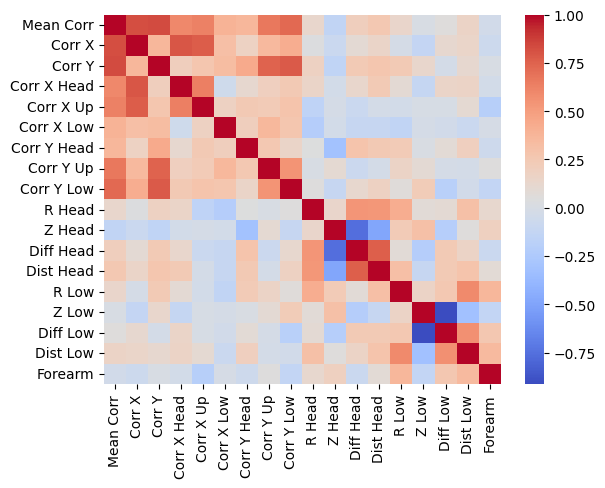

In [ ]:
import seaborn as sns

listfile = r"C:\Users\franc\Box\Rehab Robotics Lab\Projects\PANDA Gym (# 834084)\Personnel\Students & RAs\Francis Sowande\Aim 2\Analysis 2.xlsx"
# image_folder=r"C:\Users\franc\Box\Rehab Robotics Lab\Projects\PANDA Gym (# 834084)\Personnel\Students & RAs\Francis Sowande\Aim 2\Analysis 1"

df= pd.read_excel(listfile)
# print(df)
cc=["Mean Corr","Corr X",	"Corr Y","Corr X Head",	"Corr X Up","Corr X Low","Corr Y Head","Corr Y Up","Corr Y Low","R Head","Z Head","Diff Head","Dist Head","R Low","Z Low","Diff Low","Dist Low","Forearm"]
df=df.loc[:,cc]
sns.heatmap(df.corr(), cmap="coolwarm")
# plt.show()

In [ ]:
from Infant_Paramters import infant_params

param = infant_params()
age = 3 * 4
# print(age)

Ma = param.get_mass(age)
Ra = param.get_radius(age)
In = param.get_inertia(age)
Le = param.get_length(age)

# print(Ra)

months=([1,2,3,4,5,6,7,8])

print()






                   0
head       14.506326
neck        2.216503
upp trunk  13.723313
low trunk  12.239777
upp arm     8.775815
low arm     9.929741
hand        5.587967
upp leg    12.178112
low leg    11.839297
foot        9.003149


1
2
3
4
5
6
7
8
                   1          2          3          4          5          6  \
head       24.492401  24.474607  24.355222  24.185645  24.001473  23.825317   
neck        1.247063   1.272032   1.289122   1.301174   1.310319   1.318038   
upp trunk  17.813922  18.353291  18.761009  19.079252  19.340663  19.568768   
low trunk  25.264416  24.317409  23.362727  22.445333  21.590594  20.809926   
upp arm     1.964077   2.042427   2.104286    2.15447   2.196808   2.234136   
low arm     2.202017   2.172049   2.135914   2.097987   2.061121   2.026987   
hand        0.731679   0.747229   0.758062   0.765853   0.771863   0.776973   
upp leg     5.899946   6.278062   6.591714   6.856601   7.085973    7.29018   
low leg     3.127903   3.247329   3.341054   3.416697   3.480292   3.536288   
foot        1.665477   1.304235   1.184931    1.20269   1.282419   1.374412   
total          100.0      100.0      100.0      100.0      100.0      100.0   

                   7          8  
h

<Axes: >

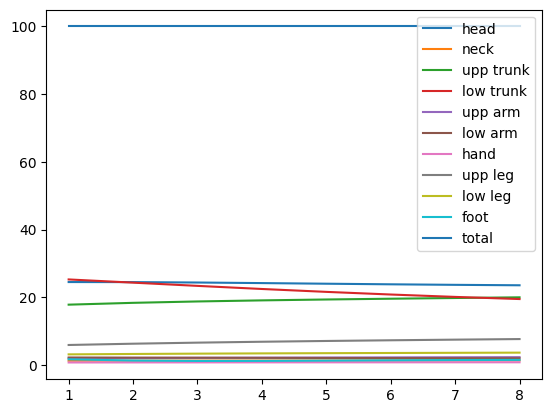

In [ ]:
indx=np.array(
            [
                "head",
                "neck",
                "upp trunk",
                "low trunk",
                "upp arm",
                "low arm",
                "hand",
                "upp leg",
                "low leg",
                "foot",
                "total"
            ]
        )

masses=pd.DataFrame(  index=indx,columns=months)

for m in masses:
    # print(m)
    ma=param.get_mass(m*4)
    ma_norm=(ma/ma.loc["total"])*100
    # print(masses.loc[indx,m])
    # print((ma_norm.loc[indx,0]))
    masses.loc[indx,m]=ma_norm.loc[indx,0]


print(masses)
masses.T.plot()

                   1          2         3          4         5          6  \
upp trunk  51.521973  52.200875  52.85701  53.491504  54.10541  54.699715   
low trunk  48.478027  47.799125  47.14299  46.508496  45.89459  45.300285   

                   7         8  
upp trunk  55.275343  55.83316  
low trunk  44.724657  44.16684  


<Axes: >

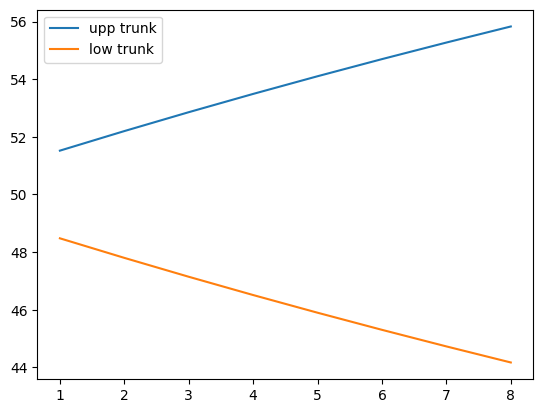

In [42]:
indx=np.array(
            [
                "upp trunk",
                "low trunk",
            ]
        )


lengths=pd.DataFrame(  index=indx,columns=months)
for m in lengths:
    # print(m)
    le=param.get_length(m*4)

    le_trunk=le.loc[indx,0]
    le_norm=((le_trunk/le_trunk.sum())*100)
    
    lengths.loc[indx,m]=le_norm.loc[indx]


print(lengths)
lengths.T.plot()

                   1          2          3          4          5          6  \
upp trunk  52.544172  53.435011  54.306945  55.160569  55.996454  56.815148   
low trunk  47.455828  46.564989  45.693055  44.839431  44.003546  43.184852   

                   7          8  
upp trunk  57.617174  58.403038  
low trunk  42.382826  41.596962  


<Axes: >

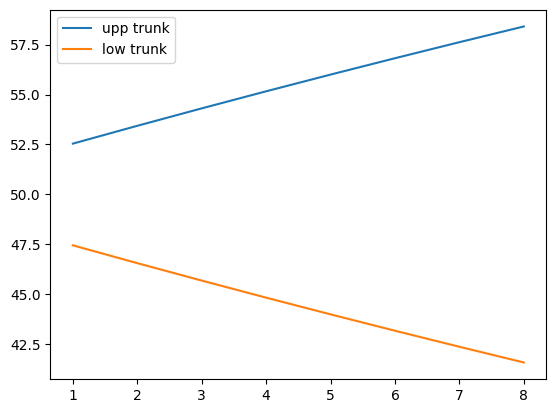

In [43]:
indx=np.array(
            [
                "upp trunk",
                "low trunk",
            ]
        )


rads=pd.DataFrame(  index=indx,columns=months)
for m in rads:
    # print(m)
    ra=param.get_radius(m*4)

    ra_trunk=ra.loc[indx,0]
    ra_norm=((ra_trunk/ra_trunk.sum())*100)
    
    rads.loc[indx,m]=ra_norm.loc[indx]


print(rads)
rads.T.plot()